DSCI 310 Final Project
Joshua Duffy

In [356]:
#Step 1: Data cleaning and preparation

In [410]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import gaussian_kde

In [411]:
#Reading in the dataset
df = pd.read_csv('/Users/joshuaduffy/Downloads/Energy_and_Water.csv',
    low_memory=False)
#We'll be using the Site Energy Use (kBtu) column to determine energy usage
#We need to first clean the data of any null values or extreme values
target = "Source EUI (kBtu/ft²)" 
#Remvoing null values
df[target] = pd.to_numeric(df[target], errors='coerce')
df = df[df[target] > 0]
#Trimming of extreme values,these can have a big effect on the Gamma regression
upper_cut = df[target].quantile(0.995)
df = df[df[target] < upper_cut]

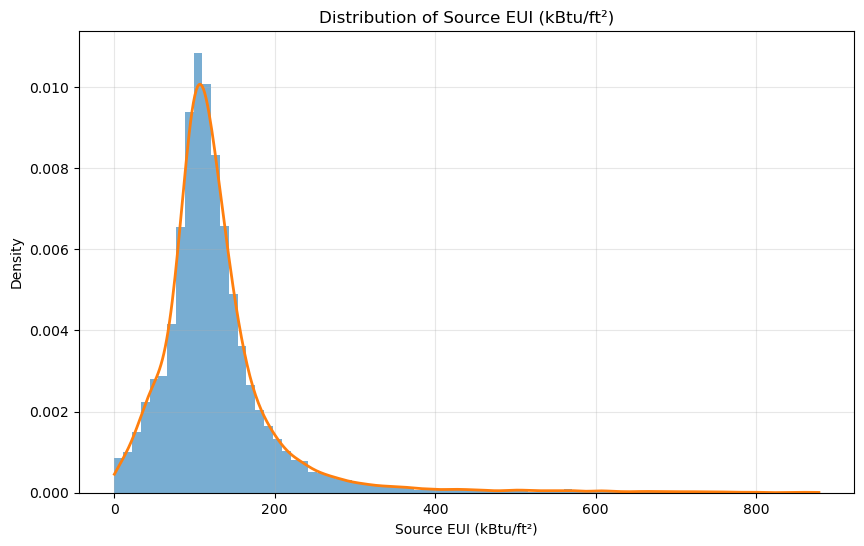

In [412]:
#Plotting the distribution of Source EUI (kBtu/ft²)
# Extracting the target variable, since target has already been trimmed, we need to 
#extract the target varaible again
y = df["Source EUI (kBtu/ft²)"].dropna()

#Creating the histogram
plt.figure(figsize=(10,6))
plt.hist(y, bins=80, density=True, alpha=0.6)

#Overlaying the kernal density estimate
kde = gaussian_kde(y)
x_vals = np.linspace(y.min(), y.max(), 500)
plt.plot(x_vals, kde(x_vals), linewidth=2)

#Labeling and final formatting
plt.xlabel("Source EUI (kBtu/ft²)")
plt.ylabel("Density")
plt.title("Distribution of Source EUI (kBtu/ft²)")
plt.grid(alpha=0.3)
plt.show()

In [413]:
#Since the formatting of the dataset is weird, we have to manually make some columns
#numerical

#Converting object columns to numeric 
df = df.apply(pd.to_numeric, errors='ignore')
#Coercing to NaN
df = df.apply(lambda col: pd.to_numeric(col, errors='coerce') 
              if col.dtype == 'object' else col)

/var/folders/h0/8fx_lpmn0c38t2hx2xdx67t00000gn/T/ipykernel_16221/2145752874.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [414]:
#Getting rid of bad predictors
bad_predictors = [
    "Property Id",
    "Number of Active IT Meters"
]
df = df.drop(columns=[c for c in bad_predictors if c in df.columns])

In [415]:
#Selecting usable numeric predictors for the regression model
#Extracting numeric all numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_predictors = [c for c in numeric_cols if c != target] #Exclude our target variable

# Removing predictors with too many missing values
numeric_predictors = [c for c in numeric_predictors if df[c].notna().sum() > 5000]
#Remove predictors with extreme outliers
numeric_predictors = [
    c for c in numeric_predictors 
    if df[c].abs().quantile(0.999) < 1e8  
]
#Removing predictors with nearly zero variance
numeric_predictors = [c for c in numeric_predictors if df[c].std() > 1e-6]

In [416]:
#Our validation MSE was exploding due to an extremely massive outlier that was 100x 
#the normal value
#Therefore we will cap predictors in the 1%-99% range
for col in numeric_predictors:
    df[col] = df[col].clip(
        df[col].quantile(0.01),
        df[col].quantile(0.99)
    )

In [426]:
#Taking care of columns with missing predictors
# Computing missing percent for all numeric predictors
missing_pct = df[numeric_predictors].isna().mean()

# Removing predictors with >10% missing
bad_predictors = missing_pct[missing_pct > 0.10].index.tolist()

# Dropping them from the dataset
df = df.drop(columns=bad_predictors)

# Updating predictor list
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_predictors = [c for c in numeric_cols if c != target]
#Dropping predictors that still contain NaNs
numeric_predictors = [
    c for c in numeric_predictors 
    if df[c].isna().sum() == 0
]
#Getting rid of columns with zero variance
numeric_predictors = [
    c for c in numeric_predictors 
    if df[c].std() > 0
]

In [427]:
#Splitting the data into training, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42)

In [428]:
# Standardizing the data
scaler = StandardScaler()
#Fitting it onto the data
train_df[numeric_predictors] = scaler.fit_transform(train_df[numeric_predictors])
val_df[numeric_predictors]   = scaler.transform(val_df[numeric_predictors])
test_df[numeric_predictors]  = scaler.transform(test_df[numeric_predictors])

In [429]:
# VIF Filtering
#Note for this part of the code, it was a suggestion by ChatGPT as a way to help
#Decrease the MSE in the Gamma model
#Method for computing the variance inflation factor for each predictor
def compute_vif(df, predictors):
    X = df[predictors].dropna()
    vif_df = pd.DataFrame()
    vif_df["feature"] = predictors
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_df

#Starting VIF filtering with all numeric predictors
vif_predictors = numeric_predictors.copy()

#Iteratively removing the worst VIF until all VIF < 10
while True:
    vif_df = compute_vif(train_df, vif_predictors)
    max_vif = vif_df["VIF"].max()
    if max_vif < 10:
        break
    drop_var = vif_df.loc[vif_df["VIF"].idxmax(), "feature"]
    vif_predictors.remove(drop_var)

print("\nRemaining predictors after VIF filtering:", len(vif_predictors))


Remaining predictors after VIF filtering: 8


In [430]:
#Building the full mddel for backward stepwise selection
# Quoting column names with Q("col")
target_q = f'Q("{target}")'
predictors_q = [f'Q("{c}")' for c in vif_predictors]
#Constructing regression formula
formula = target_q + " ~ " + " + ".join(predictors_q)

In [431]:
#Fitting the intial Gamma regression model
train_df_clean = train_df.dropna(subset=vif_predictors).copy()
#Full model from previous step
current_formula = formula
#Fitting the model
current_model = smf.glm(
    formula=current_formula,
    data=train_df_clean,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

In [432]:
#Step 2: Running the Gamma regression model

In [433]:
#Performing the backwards stepwise selection
#Looping through and extracting p-values, worst p-value is then removed
while True:
    #Getting the p-values
    pvals = current_model.pvalues.drop("Intercept")
    worst_predictor = pvals.idxmax()
    worst_p = pvals.max()

    #Stopping the process if worst p-values is less than 0.05
    if worst_p < 0.05:
        break

    #Removing the worst value from the model formula
    terms = current_formula.split("~")[1].split("+")
    terms = [t.strip() for t in terms if worst_predictor not in t]
    #Rebuilding the formula
    current_formula = target_q + " ~ " + " + ".join(terms)

    #Fitting the final model
    current_model = smf.glm(
        formula=current_formula,
        data=train_df,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()

print("\nFinal model:")
print(current_model.summary())



Final model:
                     Generalized Linear Model Regression Results                      
Dep. Variable:     Q("Source EUI (kBtu/ft²)")   No. Observations:                19371
Model:                                    GLM   Df Residuals:                    19362
Model Family:                           Gamma   Df Model:                            8
Link Function:                            Log   Scale:                        0.069901
Method:                                  IRLS   Log-Likelihood:                -96765.
Date:                        Mon, 08 Dec 2025   Deviance:                       1945.2
Time:                                13:37:11   Pearson chi2:                 1.35e+03
No. Iterations:                           100   Pseudo R-squ. (CS):             0.9642
Covariance Type:                    nonrobust                                         
                                                                        coef    std err          z      P>|z|      [

In [434]:
#Validation set
# Extracting predictors from the formula
final_terms = current_formula.split("~")[1].split("+")
final_predictors = [t.strip()[3:-2] for t in final_terms]

# Cleaning validation set before prediction
val_df_clean = val_df.dropna(subset=final_predictors).copy()

# Predicting the target value 
val_pred = current_model.predict(val_df_clean)

# Getting the metrics for the validation set
val_mse = mean_squared_error(val_df_clean[target], val_pred)
val_mae = mean_absolute_error(val_df_clean[target], val_pred)

print(f"Validation MSE: {val_mse:.2f}")
print(f"Validation MAE: {val_mae:.2f}")

Validation MSE: 4994.11
Validation MAE: 27.62


In [435]:
#Retraining 
#Combining the training and validation sets
trainval_df = pd.concat([train_df, val_df])

#Fitting the final Gamma regression model
final_model = smf.glm(
    formula=current_formula,
    data=trainval_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

In [436]:
#Test set
#Cleaning and predicting the test set data
test_df_clean = test_df.dropna(subset=final_predictors).copy()
test_pred = final_model.predict(test_df_clean)

#Getting the metrics for the test set
test_mse = mean_squared_error(test_df_clean[target], test_pred)
test_mae = mean_absolute_error(test_df_clean[target], test_pred)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Test MSE: 4839.40
Test MAE: 27.23


In [437]:
#Simulating draws for each test observation
#Extracting dispersion parameter
scale = final_model.scale

#Getting the number of simulation
n_sim = 500

# Matrix for storing simulated predictions
simulated = np.zeros((len(test_pred), n_sim))

#Doing the simulation
for i in range(n_sim):
    # Gamma parameterization
    shape = 1 / scale
    scale_param = test_pred * scale
    #Simulating one sample for each observation
    simulated[:, i] = np.random.gamma(shape=shape, scale=scale_param)

In [438]:
#Computing prediction intervals
lower_PI = np.percentile(simulated, 2.5, axis=1)
upper_PI = np.percentile(simulated, 97.5, axis=1)

In [439]:
#Getting the summary statistics for the prediction intervals
interval_width = upper_PI - lower_PI

mean_width = interval_width.mean()
std_width = interval_width.std()

print("Mean Prediction Interval Width:", mean_width)
print("Std of Prediction Interval Width:", std_width)

Mean Prediction Interval Width: 137.9470645102178
Std of Prediction Interval Width: 128.3573263274957


In [440]:
#Part 3 OLS Regression

In [441]:
#Preparing to fit OLS model
# Extracting final predictor names from the model formula
final_terms = current_formula.split("~")[1].split("+")
final_predictors = []
for t in final_terms:
    t = t.strip()
    if t.startswith('Q("') and t.endswith('")'):
        col = t[3:-2]
        final_predictors.append(col)
#Cleaning the sets
train_df_clean = train_df.dropna(subset=final_predictors + [target]).copy()
val_df_clean = val_df.dropna(subset=final_predictors + [target]).copy()
test_df_clean = test_df.dropna(subset=final_predictors + [target]).copy()

#Building the design matrices for OLS
X_train = train_df_clean[final_predictors].copy()
y_train = train_df_clean[target].copy()

X_val = val_df_clean[final_predictors].copy()
y_val = val_df_clean[target].copy()

X_test = test_df_clean[final_predictors].copy()
y_test = test_df_clean[target].copy()

# Adding intercept column
X_train = sm.add_constant(X_train, has_constant='add')
X_val   = sm.add_constant(X_val,   has_constant='add')
X_test  = sm.add_constant(X_test,  has_constant='add')

#Reseting indices due to previous issues with it
X_train, y_train = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
X_val, y_val     = X_val.reset_index(drop=True),   y_val.reset_index(drop=True)
X_test, y_test   = X_test.reset_index(drop=True),  y_test.reset_index(drop=True)

In [442]:
#Fitting the model 
ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

                              OLS Regression Results                             
Dep. Variable:     Source EUI (kBtu/ft²)   R-squared:                       0.801
Model:                               OLS   Adj. R-squared:                  0.801
Method:                    Least Squares   F-statistic:                     9725.
Date:                   Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                           13:37:44   Log-Likelihood:                -97176.
No. Observations:                  19371   AIC:                         1.944e+05
Df Residuals:                      19362   BIC:                         1.944e+05
Df Model:                              8                                         
Covariance Type:               nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [443]:
#Predicting and computing MSE and MAE
#Getting prediction values for the validation set
val_pred = ols_model.predict(X_val)

#Retraining
trainval_df = pd.concat([train_df, val_df]).copy()

#Dropping rows that contain NA in predictors or target
trainval_df_clean = trainval_df.dropna(subset=final_predictors + [target]).copy()
test_df_clean = test_df.dropna(subset=final_predictors + [target]).copy()

# Building design matrices
X_trainval = trainval_df_clean[final_predictors].copy()
y_trainval = trainval_df_clean[target].copy()

X_test = test_df_clean[final_predictors].copy()
y_test = test_df_clean[target].copy()

#Adding constant term
X_trainval = sm.add_constant(X_trainval, has_constant='add')
X_test     = sm.add_constant(X_test,     has_constant='add')

# Resetting index
X_trainval, y_trainval = X_trainval.reset_index(drop=True), y_trainval.reset_index(drop=True)
X_test,     y_test     = X_test.reset_index(drop=True),     y_test.reset_index(drop=True)

#Fitting the OLS model on train and validation
final_ols_model = sm.OLS(y_trainval, X_trainval).fit()

#Getting predicted values for test
test_pred = final_ols_model.predict(X_test)

#Getting the MSE and MAE for validation and test sets
print("Validation MSE:", mean_squared_error(y_val, val_pred))
print("Validation MAE:", mean_absolute_error(y_val, val_pred))

print("Test MSE:", mean_squared_error(y_test, test_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))

Validation MSE: 1352.9861495381954
Validation MAE: 24.50073276031509
Test MSE: 1361.4488957681028
Test MAE: 24.164361856361662


In [444]:
#Prediction intervals for OLS
#Getting prediction results
pred_res = final_ols_model.get_prediction(X_test)
#Converting to a summary frame
pred_int = pred_res.summary_frame(alpha=0.05)

#Extracting lower and upper prediction interval bounds
lower = pred_int["obs_ci_lower"].values
upper = pred_int["obs_ci_upper"].values
interval_width = upper - lower

#Getting the mean and standard deviation width
print("Mean PI Width:", interval_width.mean())
print("Std PI Width:", interval_width.std())

Mean PI Width: 143.36060730689977
Std PI Width: 0.05282435969191053
